# Letnie igrzyska olimpijskie I

Wykorzystujemy moduł Pandas do analizy dokumentu z dokonaniami medalowymi na letnich igrzyskach olimpijskich w latach 1976-2008. Plik z tabelą csv znajduje się na stronie 
[kaggle.](https://www.kaggle.com/divyansh22/summer-olympics-medals)

## Przygotowanie

In [2]:
import pandas as pd

### Wczytanie danych

UTF8 jest domyślnym kodowaniem w moim systemie operacyjnym. [Dokumentacja](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) nie mówi, jakiego kodowania używa `pd.read_csv()`, gdy brakuje parametru `encoding`. Przypuszczam, że podobnie jak dla `open()` wykorzystywane jest wtedy kodowanie ustawione jako domyślne w systemie operacyjnym. Na moim komputerze próba wczytania dokumentu bez parametru `encoding` i z `encoding='utf8'` prowadzi do wyjątku `UnicodeDecodeError`. Zatem albo dokument ma "zepsute" kodowanie UTF8 albo, co bardziej prawdopodobne, jego kodowanie jest inne. Ustawienie kodowania na zachodnioeuropejskie kodowanie MS Windows [cp1252](https://pl.wikipedia.org/wiki/Windows-1252) pozwala na wczytanie dokumentu bez wyjątku:

In [6]:
olimp = pd.read_csv(r"Summer-Olympic-medals-1976-to-2008.csv", encoding='cp1252')
olimp.head()

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976.0,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,Silver
1,Montreal,1976.0,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,Bronze
2,Montreal,1976.0,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,Gold
3,Montreal,1976.0,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,Silver
4,Montreal,1976.0,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,Bronze


Brak wyjątku nie dowodzi, że wybrane kodowanie jest poprawne. CP1252 jest prostym kodowaniem o stałej szerokości, gdzie pojedynczym bajtom przypisane są znaki, znaki kontrolne, lub ewentualnie nie jest przypisane nic. UTF8 jest kodowaniem o zmiennej szerokości, na jeden znak przypada od jeden do czterech bajtów, a sposób [mapowania znaków](https://pl.wikipedia.org/wiki/UTF-8#Spos%C3%B3b_kodowania) powoduje, że tekst zapisany w innym kodowaniu jest często niemożliwy do wczytania w UTF8. Tekst zapisany w kodowaniu innym niż cp1252 nie da się w tym kodowaniu odczytać (tzn. Python rzuci wyjątek), gdy tekst ten będzie zawierał bajty, które nie mają w tym kodowaniu przypisanej wartości. Z tabeli w linkowanej stronie widzimy, że takim bajtem jest np. `x81` czyli 129 dziesiętnie:

In [7]:
b = bytes([129])
b

b'\x81'

In [8]:
b.decode(encoding='cp1252')

UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 0: character maps to <undefined>

Jak widać, nasz dokument takich bajtów nie zawiera, więc spełniony jest warunek konieczny w wyborze kodowania. Tym niemniej w kodowaniu cp1250, czyli środkowoeuropejskim MS Windows, również wczytuje się bez wyjątku. Jeśli nie ma dokładnej informacji o kodowaniu dokumentu, to pozostaje metoda prób i błędów -- może jakiś nieprawidłowo kodowany znak zostanie dostrzeżony przypadkiem.

### Rozmiar

Tabela zawiera 15433 wiersze i 11 kolumn:

In [9]:
olimp.shape

(15433, 11)

### Braki w danych

Metoda `.isnull()` (`.isna()` jest jej aliasem) zwraca ramkę/szereg z `True` dla wartości brakujących i `False` dla występujących. Liczba wszystkich wartości brakujących:

In [12]:
olimp.isnull().sum().sum()

np.int64(1287)

Liczba wartości brakujących w każdej kolumnie osobno:

In [13]:
olimp.isnull().sum()

City            117
Year            117
Sport           117
Discipline      117
Event           117
Athlete         117
Gender          117
Country_Code    117
Country         117
Event_gender    117
Medal           117
dtype: int64

Ten wynik sugeruje, że w tabeli istnieją puste wiersze. Jest mało prawdopodobne, aby w każdej z 11 kolumn brakowało tyle samo wartości, a zarazem żeby braki nie występowały wspólnie.

Liczba wierszy bez ani jednej brakującej wartości (czyli takie, w których wszystkie wartości faktycznie istnieją). Funkcje agregujące domyślnie wykonują agregacje w kolumnach, dlatego teraz potrzebujemy parametru `axis=1`:

In [14]:
olimp.notnull().all(axis=1).sum()

np.int64(15316)

Liczba wierszy, w których występuje co najmniej jedna wartość, reszty może brakować. Mowa tu o nadzbiorze poprzedniej listy wierszy, ale wartość wypada taka sama. Wynika stąd, że wiersz który ma brak, ma w istocie brak na wszystkich pozycjach. 

In [15]:
olimp.notnull().any(axis=1).sum()

np.int64(15316)

Dla pewności sprawdźmy jeszcze, ile jest wierszy w 100% pustych:

In [16]:
olimp.isnull().all(axis=1).sum()

np.int64(117)

Wyznaczamy wiersze bez wartości:

In [17]:
olimp[olimp.isnull().all(axis=1)].index

Index([770, 771, 772, 773, 774, 775, 776, 777, 778, 779,
       ...
       877, 878, 879, 880, 881, 882, 883, 884, 885, 886],
      dtype='int64', length=117)

Zróbmy podgląd 5 wierszy przed i za luką w danych:

In [18]:
olimp.loc[765:770, :]

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
765,Montreal,1976.0,Handball,Handball,handball,"COSMA, Adrian",Men,ROU,Romania,M,Silver
766,Montreal,1976.0,Handball,Handball,handball,"RICHTER-HOCHMUT, Kristina",Women,GDR,East Germany,W,Silver
767,Montreal,1976.0,Handball,Handball,handball,"ANPILOGOV, Aleksandr",Men,URS,Soviet Union,M,Gold
768,Montreal,1976.0,Handball,Handball,handball,"PENU, Cornel",Men,ROU,Romania,M,Silver
769,Montreal,1976.0,Handball,Handball,handball,"KRAVTSOV, Vladimir",Men,URS,Soviet Union,M,Gold
770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
olimp.loc[886:891, :]

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
887,Montreal,1976.0,Handball,Handball,handball,"ISHCHENKO, Mikhail",Men,URS,Soviet Union,M,Gold
888,Montreal,1976.0,Handball,Handball,handball,"BUROSCH, Hannelore",Women,GDR,East Germany,W,Silver
889,Montreal,1976.0,Handball,Handball,handball,"BOBRUS-PARADNIK, Liudmila",Women,URS,Soviet Union,W,Gold
890,Montreal,1976.0,Handball,Handball,handball,"ILYIN, Vasili",Men,URS,Soviet Union,M,Gold
891,Montreal,1976.0,Handball,Handball,handball,"REZANOV, Aleksandr",Men,URS,Soviet Union,M,Gold


Puste wiersze możemy bez szkody usunąć, ale zanim to zrobimy, sprawdźmy ile mamy wszystkich faktycznych wartości (*non-missing*):

In [20]:
olimp.notnull().sum().sum()

np.int64(168476)

Usuwamy w miejscu:

In [21]:
olimp.dropna(inplace=True)

I znów zliczamy non-missing. Uzyskujemy ten sam wynik, czyli nie usunęliśmy żadnej występującej wartości:

In [22]:
olimp.notnull().sum().sum()

np.int64(168476)

Rozmiar nieznacznie zmalał:

In [23]:
olimp.shape

(15316, 11)

### Typy danych

In [24]:
olimp.dtypes

City             object
Year            float64
Sport            object
Discipline       object
Event            object
Athlete          object
Gender           object
Country_Code     object
Country          object
Event_gender     object
Medal            object
dtype: object

Okazuje się, że kolumna `Year` ma wartości typu float. Dlaczego? Gdyż były w niej braki, które zostały zastąpione przez `NaN`, a to jest wartość zmiennoprzecinkowa. Ponieważ wszystkie braki usunęliśmy (co nie zawsze jest możliwe), więc typ tego atrybutu możemy zamienić na bardziej odpowiedni:

In [25]:
olimp.Year = olimp.Year.astype('int')
olimp.dtypes

City            object
Year             int64
Sport           object
Discipline      object
Event           object
Athlete         object
Gender          object
Country_Code    object
Country         object
Event_gender    object
Medal           object
dtype: object

Wszystkie łańcuchy znaków są typu `object`, czyli są traktowane jako ogólne obiekty Pythona. Fakt, że atrybut jest typu `object` oznacza, że operacje na nim będą wykonywane na poziomie Pythona, a więc mało wydajnie. Oto przykład z PDSH:

In [27]:
import numpy as np

for dtype in ['object', 'int']:
    print("dtype =", dtype)
    %timeit np.arange(1E6, dtype=dtype).sum()
    print()

dtype = object
23.8 ms ± 1.28 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

dtype = int
208 μs ± 2.27 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)



Liczby względnie łatwo zamienia się wewnętrznie na jednorodną tablicę w stylu C, w tym celu wystarczy oszcować ile bajtów każda z liczb zajmie. Z łańcuchami znaków już tak prosto nie jest, gdyż łańcuchy znaków same stanowią typ tablicowy. Jeśli posiadasz wersję Pandas < 1.0, to typ `object` dla łańcuchów jest jedyną opcją. Natomiast Pandas 1.0 wprowadza (na razie ze statusem *experimental*) nowy [typ tablicowy do obsługi tekstu](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html).

Jeśli masz wcześniejszą wersję Pandas, to pozostań przy typie `object`, ja niżej przetestuję nowy typ `string`.

Wartości brakujące (na razie tylko w łańcuchach) są zastępowane przez nowy natywny w Pandas typ `pd.NA`:

In [28]:
s = pd.Series(["a", None, "b"], dtype="string")
s

0       a
1    <NA>
2       b
dtype: string

W ramce `olimp` wszystkie kolumny typu `object` zawierają dane tekstowe, to umożliwia zrzutowanie ich na typ `string`:

In [29]:
typy = olimp.dtypes == 'object'
typy

City             True
Year            False
Sport            True
Discipline       True
Event            True
Athlete          True
Gender           True
Country_Code     True
Country          True
Event_gender     True
Medal            True
dtype: bool

In [30]:
olimp.dtypes

City            object
Year             int64
Sport           object
Discipline      object
Event           object
Athlete         object
Gender          object
Country_Code    object
Country         object
Event_gender    object
Medal           object
dtype: object

In [31]:
olimp.loc[:, typy].columns

Index(['City', 'Sport', 'Discipline', 'Event', 'Athlete', 'Gender',
       'Country_Code', 'Country', 'Event_gender', 'Medal'],
      dtype='object')

In [36]:
olimp[olimp.loc[:, typy].columns] = olimp[olimp.loc[:, typy].columns].apply(lambda x: x.astype('string'))

In [37]:
olimp.dtypes

City            string[python]
Year                     int64
Sport           string[python]
Discipline      string[python]
Event           string[python]
Athlete         string[python]
Gender          string[python]
Country_Code    string[python]
Country         string[python]
Event_gender    string[python]
Medal           string[python]
dtype: object

In [38]:
olimp['City'] = olimp['City'].astype(dtype='string')

In [39]:
olimp.loc[:, typy] = olimp.loc[:, typy].astype(dtype='string')
olimp.dtypes

City            string[python]
Year                     int64
Sport           string[python]
Discipline      string[python]
Event           string[python]
Athlete         string[python]
Gender          string[python]
Country_Code    string[python]
Country         string[python]
Event_gender    string[python]
Medal           string[python]
dtype: object

### Serializacja

Zapiszmy efekty do pliku, dzięki temu unikniemy powtarzania przygotowawczych operacji przy kolejnych analizach.

Nasz zbiór danych jest bardzo mały, więc nie ma wielkiej różnicy w jakim formacie dokonamy zapisu. Warto jednak, zbyś zdawał sobie sprawę, że istnieje tu wiele różnych możliwości. Zajrzyj do oficjalnej dokumentacji [IO guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html). A [tutaj](https://towardsdatascience.com/the-best-format-to-save-pandas-data-414dca023e0d) dokonano porównania różnych formatów.

Zapis do natywnego dla Pythona formatu *pickle*:

In [40]:
olimp.to_pickle(r'summer_1976_2008.pkl')

## Kilka prostych pytań

Lata, w których organizowano letnie igrzyska olimpijskie zebrane w bazie:

In [41]:
olimp.Year.unique()

array([1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008])

In [42]:
olimp.Year.unique().size

9

Miasto organizatora:

In [43]:
olimp.City.unique()

<StringArray>
[   'Montreal',      'Moscow', 'Los Angeles',       'Seoul',   'Barcelona',
     'Atlanta',      'Sydney',      'Athens',     'Beijing']
Length: 9, dtype: string

Liczba krajów, które brały udział w przynajmniej jednych igrzyskach. Szereg typu `string` nie ma atrybutu `.size`, wykorzystujemy `.shape` zamiast tego:

In [44]:
olimp.Country_Code.unique().shape

(128,)

Wszystkie kategorie sportowe:

In [45]:
olimp.Sport.unique()

<StringArray>
[         'Aquatics',           'Archery',         'Athletics',
        'Basketball',            'Boxing',     'Canoe / Kayak',
           'Cycling',        'Equestrian',           'Fencing',
          'Football',        'Gymnastics',          'Handball',
            'Hockey',              'Judo', 'Modern Pentathlon',
            'Rowing',           'Sailing',          'Shooting',
        'Volleyball',     'Weightlifting',         'Wrestling',
      'Table Tennis',            'Tennis',         'Badminton',
          'Baseball',          'Softball',         'Taekwondo',
         'Triathlon']
Length: 28, dtype: string

Liczba dyscyplin:

In [53]:
olimp

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,Silver
1,Montreal,1976,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,Bronze
2,Montreal,1976,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,Gold
3,Montreal,1976,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,Silver
4,Montreal,1976,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,Bronze
...,...,...,...,...,...,...,...,...,...,...,...
15428,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,"GUENOT, Christophe",Men,FRA,France,M,Bronze
15429,Beijing,2008,Wrestling,Wrestling Gre-R,66 - 74kg,"KVIRKELIA, Manuchar",Men,GEO,Georgia,M,Gold
15430,Beijing,2008,Wrestling,Wrestling Gre-R,55 - 60kg,"RAHIMOV, Vitaliy",Men,AZE,Azerbaijan,M,Silver
15431,Beijing,2008,Wrestling,Wrestling Gre-R,60 - 66kg,"GUENOT, Steeve",Men,FRA,France,M,Gold


In [54]:
olimp.Discipline.unique().shape

(41,)

Liczba zdobytych medali. Metodą `.groupby()` tworzymy grupy względem rodzaju medalu, następnie agregujemy wynik metodą `.size()` zwracającą liczbę wartości w każdej z grup:

In [55]:
olimp.groupby('Medal').size()

Medal
Bronze    5258
Gold      5042
Silver    5016
dtype: int64

Liczba medali zdobytych podczas igrzysk w Seulu. To samo grupowanie, tyle że na selekcji:

In [57]:
olimp[olimp.City == 'Seoul'].groupby('Medal').size()

Medal
Bronze    535
Gold      506
Silver    505
dtype: int64

Liczba zdobytych medali w różnych latach. Wykonujemy grupowanie względem dwóch kolumn jednocześnie, następnie atrybutem `.size()` zliczamy wielkość każdej grupy. Wynikiem jest szereg z **multiindeksem**: 

In [60]:
olimp.groupby(['Year', 'Medal']).size()

Year  Medal 
1976  Bronze    447
      Gold      429
      Silver    429
1980  Bronze    472
      Gold      460
      Silver    455
1984  Bronze    500
      Gold      483
      Silver    476
1988  Bronze    535
      Gold      506
      Silver    505
1992  Bronze    596
      Gold      558
      Silver    551
1996  Bronze    634
      Gold      615
      Silver    610
2000  Bronze    685
      Gold      663
      Silver    667
2004  Bronze    679
      Gold      659
      Silver    660
2008  Bronze    710
      Gold      669
      Silver    663
dtype: int64

Rzędy multiindeksu numerowane są od lewej od zera. Metoda `.unstack()` przenosi wybrany rząd multiindeksu do poziomu indeksu kolumn:

In [62]:
olimp.groupby(['Year', 'Medal']).size().unstack()

Medal,Bronze,Gold,Silver
Year,,,
1976,447,429,429
1980,472,460,455
1984,500,483,476
1988,535,506,505
1992,596,558,551
1996,634,615,610
2000,685,663,667
2004,679,659,660
2008,710,669,663


Domyślnie `.unstack()` przenosi do kolumn indeks ostatni. Jeśli chcesz w ten sposób potraktować inny indeks, musisz go wyspecyfikować:

In [63]:
olimp.groupby(['Year', 'Medal']).size().unstack(0)

Year,1976,1980,1984,1988,1992,1996,2000,2004,2008
Medal,,,,,,,,,
Bronze,447,472,500,535,596,634,685,679,710
Gold,429,460,483,506,558,615,663,659,669
Silver,429,455,476,505,551,610,667,660,663


Ramki i szeregi posiadają metodę `.plot()`. Bez argumentów metoda ta utworzy wykres wspólny dla wszystkich kolumn:

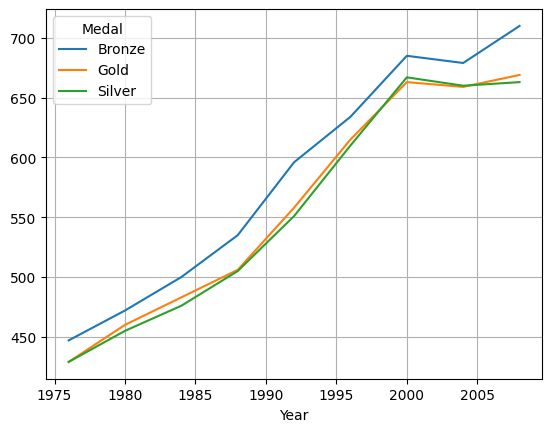

In [65]:
olimp.groupby(['Year', 'Medal']).size().unstack().plot(grid=True);

Który kraj zdobył najwięcej medali w historii igrzysk uwzględnionych w bazie? Pierwsze podejście niewiele nam daje:

In [66]:
olimp.groupby('Country').size()

Country
Afghanistan          1
Algeria             14
Argentina          153
Armenia              9
Australia          798
                  ... 
Virgin Islands*      1
West Germany       345
Yugoslavia         278
Zambia               2
Zimbabwe            23
Length: 127, dtype: int64

Szereg podany wyżej sortujemy malejąco względem **wartości:**

In [68]:
olimp.groupby('Country').size().sort_values(ascending=False).head()

Country
United States    1992
Soviet Union     1021
Australia         798
Germany           691
China             679
dtype: int64

Jakim krajem w kolumnie `Country` jest *Germany*? Spróbujmy wyznaczyć wszystkie kraje, które zawierają `'Ger'` w swojej nazwie. 

Do tego celu bardzo nam się przydadzą metody łańcuchów znaków dla szeregów (więcej na ten temat w tutorialu [B. Rhodesa](https://www.youtube.com/watch?v=5JnMutdy6Fw)). Wiele metod łańcuchów znaków znanych z Pythona stosuje się również do szeregów zawierających tekst. Aby uniknąć kolizji między nazwami metod twórcy Pandas zdecydowali się na odseparowanie metod łańcuchów od reszty metod przez umieszczenie ich w klasie `.str`. I tak, jeśli chcesz wywołać metodę `.contains()` z argumentem `'Ger'` na szeregu `s`, to musisz napisać
```python
s.str.contains('Ger')
```
Podobnie, aby nazwiska sportowców zobaczyć w stylu *title* wywołujemy metodę `.str.title()`:

Spis metod łańcuchów znaków dla szeregów znajdziesz w dokumentacji [API Reference](https://pandas.pydata.org/pandas-docs/stable/reference/series.html). Inną ważną kategorią metod odseparowaną analogicznie jak metody łańcuchów to metody daty i czasu -- w tym przypadku stosuje się notację `s.dt`.

Metody łańcuchów znaków dla szeregów są wzorowane na standardowych metodach łańcuchów w Pythonie, pamiętaj jednak, że w szczegółach zachowania metody te nie są identyczne. Na przykład wspomniana metoda `.str.contains()` akceptuje jako argument nie tylko łańcuch znaków ale i wyrażenie regularne (co może być bardzo przydatne).

Odpowiadamy na postawione wyżej pytanie: jakie kraje zawierają w swojej nazwie `Ger`?

In [73]:
olimp.Country.str.contains('Ger').head()

0     True
1    False
2    False
3    False
4    False
Name: Country, dtype: boolean

Zatem kraje zawierające `Ger` to:

In [74]:
olimp[olimp.Country.str.contains('Ger')].Country.unique()

<StringArray>
['East Germany', 'West Germany', 'Germany']
Length: 3, dtype: string

Ich osiągnięcia medalowe:

In [75]:
olimp[olimp.Country.str.contains('Ger')].Country.value_counts()

Country
Germany         691
East Germany    626
West Germany    345
Name: count, dtype: Int64

Jeśli zatem Niemcy przed i po zjednoczeniu potraktujemy jako jeden kraj, to całkowita liczba zdobytych medali będzie równa:

In [76]:
olimp[olimp.Country.str.contains('Ger')].Country.value_counts().sum()

np.int64(1662)

Który zawodnik zdobył najwięcej medali?

In [77]:
olimp.groupby('Athlete').size().sort_values(ascending=False).head(10)

Athlete
PHELPS, Michael        16
FISCHER, Birgit        12
NEMOV, Alexei          12
TORRES, Dara           12
THOMPSON, Jenny        12
ANDRIANOV, Nikolay     12
COUGHLIN, Natalie      11
BIONDI, Matthew        11
DITYATIN, Aleksandr    10
SCHERBO, Vitaly        10
dtype: int64

A który został najbardziej utytułowany przyjmując ranking punktowy:
* brąz -- 1 punkt,
* srebro -- 2 punkty,
* złoto -- 4 punkty?

Tworzymy najpierw tabelę ze sportowcami w wierszach i medalami w kolumnach: 

In [80]:
olimp.groupby(['Athlete', 'Medal']).size().unstack()

Medal,Bronze,Gold,Silver
Athlete,,,
"AAMODT, Ragnhild",NaN,1.0,NaN
"AARDENBURG, Willemien",1.0,NaN,NaN
"AARDEWIJN, Pepijn",NaN,NaN,1.0
"AARONES, Ann Kristin",1.0,NaN,NaN
"ABAJO, Jose Luis",1.0,NaN,NaN
...,...,...,...
"ZYCH, Boguslaw",1.0,NaN,NaN
"ZYKINA, Olesya",1.0,NaN,1.0
"ZÜHLKE, Steffen",1.0,NaN,NaN


Pojawiły się `NaN` i wskutek tego wartości zostały zrzutowane na float. 

W naszym przypadku wartość `NaN` oznacza, że dany sportowiec danego medalu nigdy nie zdobył, a zatem jest to wartość 0:  

In [81]:
df = olimp.groupby(['Athlete', 'Medal']).size().unstack().fillna(0).astype('int')
df.head()

Medal,Bronze,Gold,Silver
Athlete,,,
"AAMODT, Ragnhild",0,1,0
"AARDENBURG, Willemien",1,0,0
"AARDEWIJN, Pepijn",0,0,1
"AARONES, Ann Kristin",1,0,0
"ABAJO, Jose Luis",1,0,0


Uzupełniamy ramkę `df` o nową kolumnę z rankingiem:

In [82]:
df['Ranking'] = 4*df.Gold + 2*df.Silver + df.Bronze
df.head()

Medal,Bronze,Gold,Silver,Ranking
Athlete,,,,
"AAMODT, Ragnhild",0,1,0,4
"AARDENBURG, Willemien",1,0,0,1
"AARDEWIJN, Pepijn",0,0,1,2
"AARONES, Ann Kristin",1,0,0,1
"ABAJO, Jose Luis",1,0,0,1


Pozostało wykonać sortowanie. Tym razem sortujemy **całą** ramkę względem wartości z wybranej kolumny. Sortowanie to wykonamy w miejscu (parametr `inplace=True`):

In [83]:
df.sort_values(by='Ranking', ascending=False, inplace=True)
df.head(10)

Medal,Bronze,Gold,Silver,Ranking
Athlete,,,,
"PHELPS, Michael",2,14,0,58
"FISCHER, Birgit",0,8,4,40
"THOMPSON, Jenny",1,8,3,39
"LEWIS, Carl",0,9,1,38
"BIONDI, Matthew",1,8,2,37
"ANDRIANOV, Nikolay",2,6,4,34
"SCHERBO, Vitaly",4,6,0,28
"TORRES, Dara",4,4,4,28
"HALL, Gary Jr.",2,5,3,28


Fakt, że złoto znajduje się między brązem i srebrem psuje czytelność tabeli. Wygodną kolejność kolumn wprowadzimy stosując wymyślne indeksowanie (*fancy indexing*):

In [85]:
'Gold Silver Bronze Ranking'.split()

['Gold', 'Silver', 'Bronze', 'Ranking']

In [86]:
df = df[['Gold', 'Silver', 'Bronze', 'Ranking']]
df.head(10)

Medal,Gold,Silver,Bronze,Ranking
Athlete,,,,
"PHELPS, Michael",14,0,2,58
"FISCHER, Birgit",8,4,0,40
"THOMPSON, Jenny",8,3,1,39
"LEWIS, Carl",9,1,0,38
"BIONDI, Matthew",8,2,1,37
"ANDRIANOV, Nikolay",6,4,2,34
"SCHERBO, Vitaly",6,0,4,28
"TORRES, Dara",4,4,4,28
"HALL, Gary Jr.",5,3,2,28


Na koniec: przyjmując ten sam ranking punktowy co wyżej, wyznacz 10 najbardziej utytułowanych medalistów w kategorii *Cycling*:

In [87]:
s = olimp.groupby('Sport Athlete Medal'.split()).size()
s.head(5)

Sport     Athlete             Medal 
Aquatics  ABARCA, Jose Maria  Gold      1
          ABDO, Reema         Bronze    1
          ABRAHAM, Gary       Bronze    1
          ADLINGTON, Rebecca  Gold      2
          ADRIAN, Nathan      Gold      1
dtype: int64

In [88]:
df = s.loc['Cycling'].unstack().fillna(0).astype('int')
df.head()

Medal,Bronze,Gold,Silver
Athlete,,,
"ABASSOVA, Tamilla",0,0,1
"ABSALON, Julien",0,2,0
"ACHERMANN, Alfred",0,0,1
"AITKEN, Brett",1,1,1
"ALBER, Reinhard",1,0,0


In [89]:
df['Ranking'] = 4*df.Gold + 2*df.Silver + df.Bronze
df.sort_values(by='Ranking', ascending=False, inplace=True)
df = df['Gold Silver Bronze Ranking'.split()]
df.head(10)

Medal,Gold,Silver,Bronze,Ranking
Athlete,,,,
"ZIJLAARD-VAN MOORSEL, Leontien",4,1,1,19
"HOY, Chris",4,1,0,18
"WIGGINS, Bradley",3,1,2,16
"ROUSSEAU, Florian",3,1,0,14
"FIEDLER, Jens",3,0,2,14
"LLANERAS, Joan",2,2,0,12
"LEHMANN, Jens",2,2,0,12
"BALLANGER, Felicia",3,0,0,12
"EKIMOV, Vyacheslav",2,1,0,10
